In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.dropna(inplace=True)

In [4]:
df.shape

(714, 3)

In [5]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [10]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [11]:
accuracy_score(y_test,y_pred)

0.6433566433566433

In [14]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6359154929577464)

In [27]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [28]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [29]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

C:\Users\Lenova\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\Lenova\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [30]:
trf.named_transformers_['first'].n_bins_

array([15])

In [31]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [32]:
output['age_labels']=pd.cut(x=X_train['Age'],
                            bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels']=pd.cut(x=X_train['Fare'],
                            bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [33]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
614,35.0,10.0,8.0500,3.0,"(32.0, 35.0]","(7.896, 8.158]"
27,19.0,3.0,263.0000,14.0,"(16.0, 19.0]","(108.9, 512.329]"
631,51.0,13.0,7.0542,0.0,"(47.0, 54.0]","(0.0, 7.25]"
20,35.0,10.0,26.0000,9.0,"(32.0, 35.0]","(18.75, 26.0]"
257,30.0,8.0,86.5000,13.0,"(28.0, 30.0]","(76.292, 108.9]"


In [34]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2= clf.predict(X_test_trf)

In [35]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [40]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
    ])


    X_trf = trf.fit_transform(X)


    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))



    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title('Before')
        
    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title('After')
    plt.show()


    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title('Before')
        
    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title('After')

    plt.show()

0.634546165884194


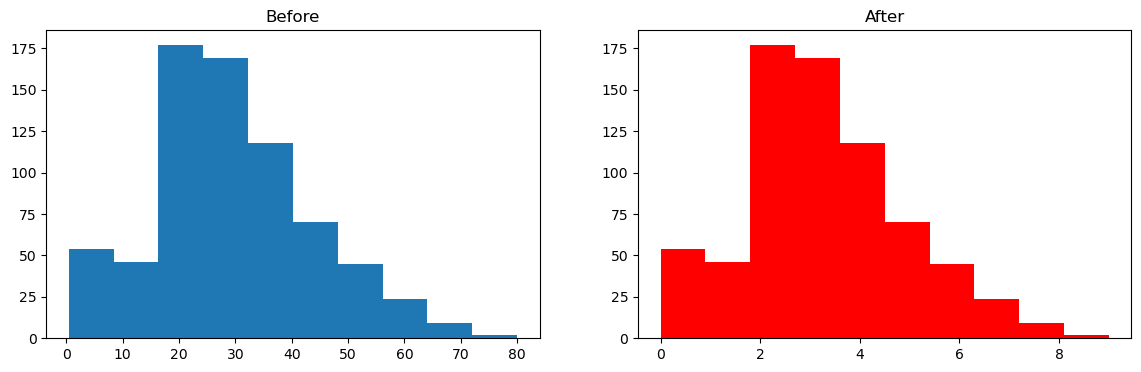

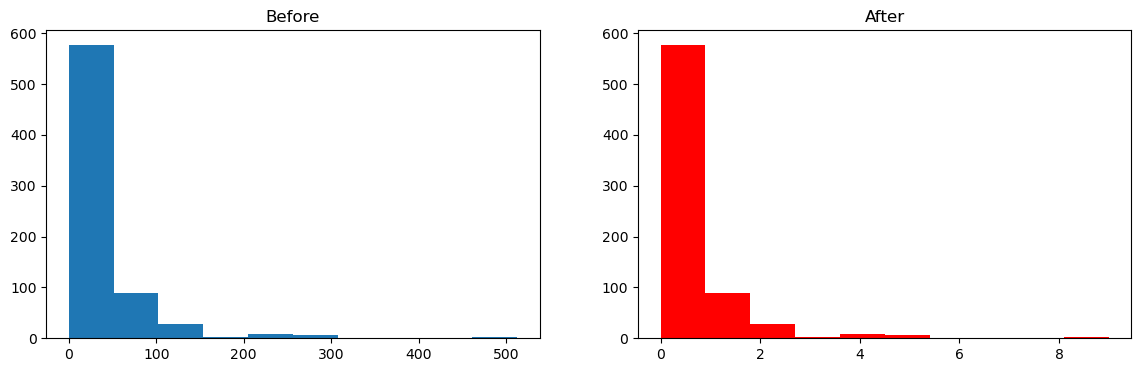

In [41]:
discretize(10,'uniform')
# discretize(10,'quantile')